# Deep Neural Network with L2-regularization and Dropout

In [348]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

### Loading the Dataset from sklearn.datasets, Visualizing and Splitting It

In [349]:
X, Y = make_moons(n_samples=400, noise=0.2, random_state=42)

In [350]:
X = X.T
Y = Y.reshape(1, -1)

In [351]:
print(X.shape, Y.shape)

(2, 400) (1, 400)


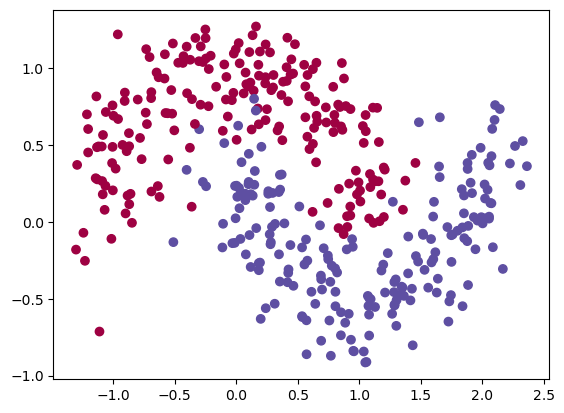

In [352]:
plt.scatter(X[0, :], X[1, :], c = Y.ravel(), cmap = 'Spectral')
plt.show()

In [353]:
from sklearn.model_selection import train_test_split
X_raw, Y_raw = make_moons(n_samples = 500, noise = 0.2, random_state = 42)
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(X_raw, Y_raw, test_size = 0.2, random_state = 42)
X_train = X_train_raw.T
X_test = X_test_raw.T
Y_train = Y_train_raw.reshape(1, -1)
Y_test = Y_test_raw.reshape(1, -1)
print(f'Train Set Shapes - X: {X_train.shape}, Y: {Y_train.shape}')
print(f'Test Set Shapes - X: {X_test.shape}, Y: {Y_test.shape}')


Train Set Shapes - X: (2, 400), Y: (1, 400)
Test Set Shapes - X: (2, 100), Y: (1, 100)


### Initializing Parameters 


In [354]:
def initialize_parameters(layer_dims = []):
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l - 1]) * np.sqrt(2 / layer_dims[l - 1])
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

In [355]:
# Checking if we initialize parameters correctly

dims = [X.shape[0], 20, 10, 1]
params = initialize_parameters(dims)
print("W1 shape:", params["W1"].shape)
print("b1 shape:", params["b1"].shape)
print("W2 shape:", params["W2"].shape)
print("b2 shape:", params["b2"].shape)

W1 shape: (20, 2)
b1 shape: (20, 1)
W2 shape: (10, 20)
b2 shape: (10, 1)


### Model Architecture

Input Layer: 2 neurons -> Hidden Layer 1: 20 neurons, ReLU -> Hidden Layer 2: 10 neurons, ReLU -> Hidden Layer 3: 5 neurons, ReLU -> Output Layer: 1 neuron, Sigmoid

In [356]:
# Building the activation functions ReLU and Sigmoid 

def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [357]:
def forward_pass(X, parameters, keep_prob = 1.0):
    cache = {}
    cache['A0'] = X
    L = len(parameters) // 2
    for l in range(1, L):
        Z = np.dot(parameters['W' + str(l)], cache['A' + str(l - 1)]) + parameters['b' + str(l)]
        cache['Z' + str(l)] = Z
        cache['A' + str(l)] = relu(Z)
        D = np.random.rand(cache['A' + str(l)].shape[0], cache['A' + str(l)].shape[1])
        cache['D' + str(l)] = D
        D = (D < keep_prob).astype(int)
        cache['A' + str(l)] = (cache['A' + str(l)] * D) / keep_prob
    ZL = np.dot(parameters['W' + str(L)], cache['A' + str(L - 1)]) + parameters['b' + str(L)]
    cache['A' + str(L)] = sigmoid(ZL)
    cache['Z' + str(L)] = ZL
    return cache['A' + str(L)], cache

In [358]:
AL, cache = forward_pass(X, params, keep_prob = 0.6)

In [359]:
def compute_cost_L2_reg(AL, Y, parameters, lambd):
    m = Y.shape[1]
    AL = np.clip(AL, 1e-15, 1.0 - 1e-15) # to prevent nan and log(0) issues when iterating over the layers in the L2 cost computations 
    cross_entropy_cost = -(1.0 / m) * np.sum(Y * np.log(AL) + (1.0 - Y) * np.log(1.0 - AL))
    l2_cost = 0
    L = len(parameters) // 2
    for l in range(1, L + 1):
        l2_cost += np.sum(np.square(parameters['W' + str(l)]))
        l2_cost *= lambd / (2 * m)
        total_cost = cross_entropy_cost + l2_cost
    return np.squeeze(total_cost)

In [360]:
def backprop(X, Y, cache, parameters, lambd, keep_prob = 1.0):
    m = Y.shape[1]
    L = len(parameters) // 2
    grads = {}
    dZ = cache['A' + str(L)] - Y
    grads['dW' + str(L)] = (1.0 / m) * np.dot(dZ, cache['A' + str(L - 1)].T) + (lambd / m) * parameters['W' + str(L)]
    grads['db' + str(L)] = (1.0 / m) * np.sum(dZ, axis = 1, keepdims = True)
    for l in reversed(range(1, L)):
        dA = np.dot(parameters['W' + str(l + 1)].T, dZ)
        dA *= cache['D' + str(l)]
        dA /= keep_prob
        dZ = np.array(dA, copy = True)
        dZ[cache['Z' + str(l)] <= 0] = 0
        grads['dW' + str(l)] = (1.0 / m) * np.dot(dZ, cache['A' + str(l - 1)].T) + (lambd / m) * parameters['W' + str(l)]
        grads['db' + str(l)] = (1.0 / m) * np.sum(dZ, axis = 1, keepdims = True)    
    return grads

### Updating Parameters and Running the Training Process with Predictions 

In [361]:
def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
        parameters['b' + str(l)] -= learning_rate * grads['db' + str(l)]
    return parameters

In [362]:
def model(X, Y, layer_dims, learning_rate = 0.01, num_iter = 30000, lambd = 0, keep_prob = 1.0):
    parameters = initialize_parameters(layer_dims)
    costs = []
    for iteration in range(num_iter):
        AL, cache = forward_pass(X, parameters, keep_prob)
        cost = compute_cost_L2_reg(AL, Y, parameters, lambd)
        grads = backprop(X, Y, cache, parameters, lambd, keep_prob)
        parameters = update_parameters(parameters, grads, learning_rate)
        if iteration % 5000 == 0:
            costs.append(cost)
            print(f'cost after iteration {iteration}: {cost}')
    return parameters, costs

In [363]:
def predict(X, Y, parameters):
    m = X.shape[1]
    AL, _ = forward_pass(X, parameters, keep_prob=1.0)
    predictions = (AL > 0.5).astype(int)
    accuracy = np.sum(predictions == Y) / m
    print(f"Accuracy: {accuracy * 100:.2f}%")
    return predictions

In [364]:
def plot(model_func, X, Y):
    x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
    y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()].T
    Z, _ = model_func(grid_points)
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.5)
    plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap=plt.cm.Spectral, edgecolors='k')
    plt.show()

### Starting the Training

******************************************* NO REGULARIZATION *******************************************
cost after iteration 0: 0.8175467200270568


cost after iteration 5000: 0.047476595499697204
cost after iteration 10000: 0.036823202999744016
cost after iteration 15000: 0.024135642931285926
cost after iteration 20000: 0.013141656344578964
cost after iteration 25000: 0.007429841198218659


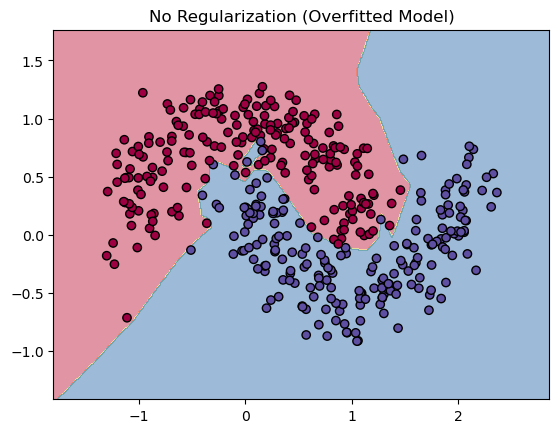

In [365]:
print('******************************************* NO REGULARIZATION *******************************************')
parameters_base, costs_base = model(
    X, Y, layer_dims = [X.shape[0], 20, 10, 5, 1], 
    learning_rate=0.3, 
    num_iter=30000, 
    lambd=0, 
    keep_prob=1.0
)
plt.title('No Regularization (Overfitted Model)')
plot(lambda x: forward_pass(x, parameters_base, keep_prob=1.0), X, Y)

In [366]:
print("Train Set:")
predictions_train = predict(X_train, Y_train, parameters_base)

print("\nTest Set")
predictions_test = predict(X_test, Y_test, parameters_base)

Train Set:
Accuracy: 97.50%

Test Set
Accuracy: 98.00%


******************************************* L2 AND DROPOUT USED *******************************************
cost after iteration 0: 0.7223540446890963
cost after iteration 5000: 0.3497636682245737
cost after iteration 10000: 0.4000725284665484
cost after iteration 15000: 0.39859773061409964
cost after iteration 20000: 0.37724894940516046
cost after iteration 25000: 0.3283605340676218
cost after iteration 30000: 0.3615258428328739
cost after iteration 35000: 0.39736394136153513


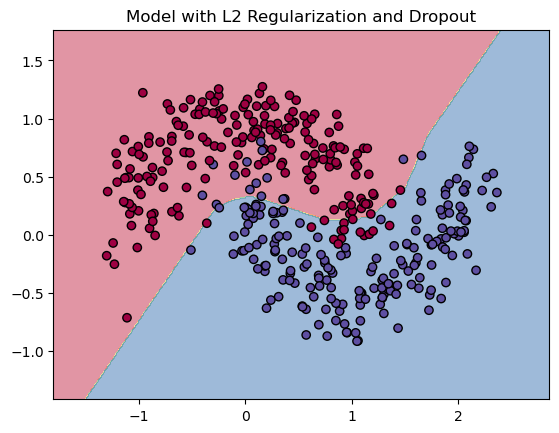

In [369]:
print('******************************************* L2 AND DROPOUT USED *******************************************')
parameters_reg, costs_reg = model(
    X, Y, layer_dims = [X.shape[0], 20, 10, 5, 1], 
    learning_rate = 0.1, 
    num_iter = 40000, 
    lambd = 0.7, 
    keep_prob = 0.9
)
plt.title('Model with L2 Regularization and Dropout')
plot(lambda x: forward_pass(x, parameters_reg, keep_prob = 1.0), X, Y)

In [370]:
print("Train Set:")
predictions_train = predict(X_train, Y_train, parameters_reg)

print("\nTest Set:")
predictions_test = predict(X_test, Y_test, parameters_reg)

Train Set:
Accuracy: 93.75%

Test Set:
Accuracy: 91.00%
